# HMC-NUTS retrieval with DiffGrid

This tutorial fits a high-resolution methane emission spectrum with HMC-NUTS using the pressure-layer aligned `OpaDiffgrid` opacity calculator. It follows the same physical example and inference flow as the corresponding PreMODIT tutorial: a power-law temperature profile, CH$_4$ line opacity, H$_2$--H$_2$ collision-induced absorption (CIA), rotational broadening, and an instrumental response.

DiffGrid stores $\log \sigma$ and $\partial \log \sigma/\partial(1/T)$ at fixed atmospheric pressures. The table is built once from a differentiable opacity calculator; here, `OpaPremodit` is the teacher. NUTS then differentiates the ordinary JAX cubic Hermite interpolation used by `OpaDiffgrid`.

The example uses the wavelength sampling and physical setup of the methane mock spectrum in the PreMODIT retrieval tutorial. To keep the mock observation exactly consistent with the current radiative-transfer implementation, its noiseless flux is generated below with the current `OpaPremodit` teacher. The YT10to10 line list is not packaged with ExoJAX and is downloaded by `MdbExomol` when it is not already available locally.

The workflow is:

1. create the observation sampling grid,
2. build the PreMODIT teacher and the pressure-aligned DiffGrid table,
3. generate a reproducible mock observation and verify the interpolation in units of its noise,
4. run one DiffGrid HMC-NUTS retrieval, and
5. inspect the posterior predictive spectrum and parameter correlations.

The table construction and NUTS cells are intended for a GPU. Use more chains and samples than this tutorial for scientific inference.

In [1]:
import arviz as az
import jax
from jax import config
config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
from numpyro.diagnostics import hpdi
from numpyro.infer import MCMC, NUTS, Predictive
from numpyro.infer.initialization import init_to_value

from exojax.database import molinfo
from exojax.database.cia.api import CdbCIA
from exojax.database.exomol.api import MdbExomol
from exojax.opacity import OpaCIA, OpaDiffgrid, OpaPremodit
from exojax.postproc.response import ipgauss_sampling
from exojax.postproc.spin_rotation import convolve_rigid_rotation
from exojax.rt import ArtEmisPure
from exojax.utils.astrofunc import gravity_jupiter
from exojax.utils.grids import velocity_grid, wavenumber_grid
from exojax.utils.instfunc import resolution_to_gaussian_std

jax.devices()

[CudaDevice(id=0)]

## Observation sampling grid

We create the same observation coordinates as the PreMODIT example. After constructing the current teacher, we generate the noiseless flux at known parameters and add Gaussian noise with a fixed NumPy seed. Generating the mock in the same run avoids coupling the retrieval to historical changes in the radiative-transfer implementation.

In [2]:
number_of_observed_wavenumbers = 1500
nu_data, wavelength_data, _ = wavenumber_grid(
    16370.0,
    16550.0,
    number_of_observed_wavenumbers,
    unit="AA",
    xsmode="modit",
    wavelength_order="ascending",
)

noise_sigma = 0.05
flux_scale = 20000.0

xsmode =  modit
xsmode assumes ESLOG in wavenumber space: xsmode=modit
Your wavelength grid is in ***  ascending  *** order
The wavenumber grid is in ascending order by definition.
Please be careful when you use the wavelength grid.


/home/kawahara/exojax/src/exojax/utils/grids.py:85: UserWarning: Both input wavelength and output wavenumber are in ascending order.
  warnings.warn(
/home/kawahara/exojax/src/exojax/utils/grids.py:249: UserWarning: Resolution may be too small. R=137073.85617245853
  warnings.warn("Resolution may be too small. R=" + str(resolution), UserWarning)


## Spectral grid and atmosphere

DiffGrid is tied to the exact pressure layers used at construction. Its temperature nodes must cover every layer temperature that can be evaluated during inference.

Here, `ArtEmisPure.powerlaw_temperature` clips the temperature profile to 400--1500 K. We use the same limits for the PreMODIT teacher and the DiffGrid table.

In [3]:
number_of_wavenumbers = 7500
nu_grid, wavelength_grid, resolution = wavenumber_grid(
    np.min(wavelength_data) - 10.0,
    np.max(wavelength_data) + 10.0,
    number_of_wavenumbers,
    unit="AA",
    xsmode="diffgrid",
    wavelength_order="ascending",
)

temperature_min = 400.0
temperature_max = 1500.0
art = ArtEmisPure(
    nu_grid=nu_grid,
    pressure_top=1.0e-8,
    pressure_btm=1.0e2,
    nlayer=100,
)
art.change_temperature_range(temperature_min, temperature_max)

planet_mass = 33.2
instrument_resolution = 100000.0
instrument_beta = resolution_to_gaussian_std(instrument_resolution)

xsmode =  diffgrid
xsmode assumes ESLOG in wavenumber space: xsmode=diffgrid
Your wavelength grid is in ***  ascending  *** order
The wavenumber grid is in ascending order by definition.
Please be careful when you use the wavelength grid.
rtsolver:  ibased
Intensity-based n-stream solver, isothermal layer (e.g. NEMESIS, pRT like)


/home/kawahara/exojax/src/exojax/utils/grids.py:249: UserWarning: Resolution may be too small. R=617160.1067701889
  warnings.warn("Resolution may be too small. R=" + str(resolution), UserWarning)


## Build the DiffGrid opacity

YT10to10 contains about 80 million transitions in this spectral interval, so loading the database and constructing the teacher can take time. The PreMODIT settings below mirror the corresponding example and define the mock observation used in this run. The teacher is needed only while the DiffGrid table is built.

Cubic Hermite interpolation is performed in inverse temperature. We therefore place the nodes uniformly in $1/T$. The example starts with 21 nodes; the validation below determines whether that is sufficient for the intended noise level.

In [4]:
mdb = MdbExomol(
    ".database/CH4/12C-1H4/YT10to10/",
    nurange=nu_grid,
    gpu_transfer=False,
)
print("number of CH4 lines:", len(mdb.nu_lines))

teacher = OpaPremodit(
    mdb=mdb,
    nu_grid=nu_grid,
    diffmode=1,
    auto_trange=(temperature_min, temperature_max),
    broadening_resolution={"mode": "manual", "value": 0.2},
    wavelength_order="ascending",
)

number_of_temperature_nodes = 21
inverse_temperature_nodes = np.linspace(
    1.0 / temperature_max,
    1.0 / temperature_min,
    number_of_temperature_nodes,
)
temperature_nodes = 1.0 / inverse_temperature_nodes

opa = OpaDiffgrid(
    teacher,
    temperature_grid=temperature_nodes,
    pressure_grid=np.asarray(art.pressure),
)
jax.block_until_ready(opa.log_cross_section_grid)
jax.block_until_ready(opa.log_cross_section_derivative_grid)

# Validate once outside JIT or NUTS. Compiled calls omit pressure.
opa.check_pressure_grid(art.pressure)
print("DiffGrid table shape:", opa.log_cross_section_grid.shape)

radis== 0.15.2
HITRAN exact name= (12C)(1H)4
HITRAN exact name= (12C)(1H)4
radis engine =  pytables


/home/kawahara/exojax/src/exojax/database/_common/radis_adapter.py:63: UserWarning: The current version of radis does not support broadf_download (requires >=0.16).
  warnings.warn(msg, UserWarning)
/home/kawahara/exojax/src/exojax/utils/molname.py:197: FutureWarning: e2s will be replaced to exact_molname_exomol_to_simple_molname.
  warnings.warn(
/home/kawahara/exojax/src/exojax/utils/molname.py:91: FutureWarning: exojax.utils.molname.exact_molname_exomol_to_simple_molname will be replaced to radis.api.exomolapi.exact_molname_exomol_to_simple_molname.
  warnings.warn(
/home/kawahara/exojax/src/exojax/utils/molname.py:63: UserWarning: No isotope number identified.
  warnings.warn("No isotope number identified.", UserWarning)
/home/kawahara/exojax/src/exojax/utils/molname.py:91: FutureWarning: exojax.utils.molname.exact_molname_exomol_to_simple_molname will be replaced to radis.api.exomolapi.exact_molname_exomol_to_simple_molname.
  warnings.warn(
/home/kawahara/exojax/src/exojax/databa

Molecule:  CH4
Isotopologue:  12C-1H4
Background atmosphere:  H2
ExoMol database:  None
Local folder:  .database/CH4/12C-1H4/YT10to10
Transition files: 
     => File 12C-1H4__YT10to10__06000-06100.trans
     => File 12C-1H4__YT10to10__06100-06200.trans


Broadener:  H2


Broadening code level: a1


...

number of CH4 lines: 80505310
default elower grid trange (degt) file version: 2
Robust range: 393.5569458240504 - 1647.2060977798953 K


/home/kawahara/exojax/src/exojax/utils/grids.py:85: UserWarning: Both input wavelength and output wavenumber are in ascending order.
  warnings.warn(


max value of  ngamma_ref_grid : 4.119208887336048
min value of  ngamma_ref_grid : 3.3534157619544067
ngamma_ref_grid grid : [3.35341549 3.71664096 4.11920929]
max value of  n_Texp_grid : 0.5
min value of  n_Texp_grid : 0.4
n_Texp_grid grid : [0.39999998 0.50000006]


Premodit: Twt= 483.67862012986944 K Tref= 1171.1891720056747 K


DiffGrid table shape: (100, 21, 7500)


## Continuum and spectral response

We add H$_2$--H$_2$ CIA and apply the same rotational and instrumental broadening as in the PreMODIT retrieval example.

In [5]:
cia_database = CdbCIA(
    ".database/H2-H2_2011.cia",
    nurange=nu_grid,
)
opa_cia = OpaCIA(cdb=cia_database, nu_grid=nu_grid)

mean_molecular_weight = 2.33
hydrogen_mass_mixing_ratio = 0.74
hydrogen_molecular_mass = molinfo.molmass_isotope("H2")
hydrogen_volume_mixing_ratio = (
    hydrogen_mass_mixing_ratio
    * mean_molecular_weight
    / hydrogen_molecular_mass
)

maximum_vsini = 100.0
velocity_array = velocity_grid(resolution, maximum_vsini)

Load CIA:  H2-H2


## Forward model, mock observation, and interpolation check

Inside the compiled DiffGrid model, call `xsmatrix(temperature)` without a pressure argument. Pressure is already bound to the table, and traced pressure arguments are intentionally rejected.

The teacher spectrum at the generating parameters becomes the noiseless mock observation. Before discarding the teacher, we also compare it with DiffGrid at those parameters and at all four corners of the temperature prior. The relevant scale is the observational uncertainty, rather than a relative error in very weak individual cross sections. If the maximum difference is not negligible compared with `noise_sigma`, increase `number_of_temperature_nodes` and rebuild the table.

mock parameters              0.000210
prior corner 1000 K, 0.05    0.000029
prior corner 1000 K, 0.20    0.000213
prior corner 1500 K, 0.05    0.000625
prior corner 1500 K, 0.20    0.000344
Name: maximum interpolation error / noise, dtype: float64


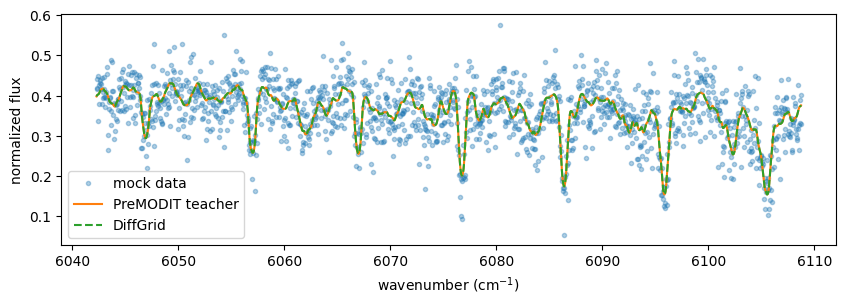

In [6]:
def forward_model(
    opacity,
    temperature,
    methane_mass_mixing_ratio,
    radius,
    radial_velocity,
    vsini,
):
    gravity = gravity_jupiter(Rp=radius, Mp=planet_mass)

    if opacity.method == "diffgrid":
        cross_section = opacity.xsmatrix(temperature)
    else:
        cross_section = opacity.xsmatrix(temperature, art.pressure)

    methane_profile = art.constant_mmr_profile(
        methane_mass_mixing_ratio
    )
    optical_depth_methane = art.opacity_profile_xs(
        cross_section,
        methane_profile,
        opacity.molmass,
        gravity,
    )

    log_cia = opa_cia.logacia_matrix(temperature)
    optical_depth_cia = art.opacity_profile_cia(
        log_cia,
        temperature,
        hydrogen_volume_mixing_ratio,
        hydrogen_volume_mixing_ratio,
        mean_molecular_weight,
        gravity,
    )

    raw_flux = art.run(
        optical_depth_methane + optical_depth_cia,
        temperature,
    ) / flux_scale
    rotational_flux = convolve_rigid_rotation(
        raw_flux,
        velocity_array,
        vsini,
        u1=0.0,
        u2=0.0,
    )
    return ipgauss_sampling(
        nu_data,
        nu_grid,
        rotational_flux,
        instrument_beta,
        radial_velocity,
        velocity_array,
    )


truth = {
    "radius": 0.88,
    "radial_velocity": 10.0,
    "methane_mass_mixing_ratio": 0.0059,
    "temperature_at_1bar": 1200.0,
    "temperature_index": 0.1,
    "vsini": 20.0,
}

temperature_at_1bar_bounds = (1000.0, 1500.0)
temperature_index_bounds = (0.05, 0.2)
validation_profiles = [
    (
        "mock parameters",
        truth["temperature_at_1bar"],
        truth["temperature_index"],
    ),
    *(
        (f"prior corner {T0:.0f} K, {alpha:.2f}", T0, alpha)
        for T0 in temperature_at_1bar_bounds
        for alpha in temperature_index_bounds
    ),
]
validation_error_in_noise = {}
for label, T0, alpha in validation_profiles:
    temperature = art.powerlaw_temperature(T0, alpha)
    arguments = (
        temperature,
        truth["methane_mass_mixing_ratio"],
        truth["radius"],
        truth["radial_velocity"],
        truth["vsini"],
    )
    candidate_diffgrid_flux = forward_model(opa, *arguments)
    candidate_teacher_flux = forward_model(teacher, *arguments)
    jax.block_until_ready(candidate_diffgrid_flux)
    jax.block_until_ready(candidate_teacher_flux)
    validation_error_in_noise[label] = float(
        jnp.max(
            jnp.abs(candidate_diffgrid_flux - candidate_teacher_flux)
        )
        / noise_sigma
    )
    if label == "mock parameters":
        diffgrid_flux = candidate_diffgrid_flux
        teacher_flux = candidate_teacher_flux

noise_rng = np.random.default_rng(1)
observed_flux = np.asarray(teacher_flux) + noise_rng.normal(
    0.0, noise_sigma, len(nu_data)
)

print(
    pd.Series(
        validation_error_in_noise,
        name="maximum interpolation error / noise",
    )
)

plt.figure(figsize=(10, 3))
plt.plot(nu_data, observed_flux, ".", alpha=0.35, label="mock data")
plt.plot(nu_data, teacher_flux, label="PreMODIT teacher")
plt.plot(
    nu_data,
    diffgrid_flux,
    "--",
    label="DiffGrid",
)
plt.xlabel("wavenumber (cm$^{-1}$)")
plt.ylabel("normalized flux")
plt.legend()
plt.show()

# The retrieval no longer needs the teacher or the line database.
del teacher, mdb

## NumPyro model

We infer the radius, radial velocity, methane mass mixing ratio, temperature normalization and index, and projected rotation speed. The opacity calculation in every likelihood evaluation now uses only `OpaDiffgrid`.

In [7]:
def model(observation=None):
    radius = numpyro.sample(
        "radius",
        dist.Uniform(0.4, 1.2),
    )
    radial_velocity = numpyro.sample(
        "radial_velocity",
        dist.Uniform(5.0, 15.0),
    )
    methane_mass_mixing_ratio = numpyro.sample(
        "methane_mass_mixing_ratio",
        dist.Uniform(0.0, 0.015),
    )
    temperature_at_1bar = numpyro.sample(
        "temperature_at_1bar",
        dist.Uniform(*temperature_at_1bar_bounds),
    )
    temperature_index = numpyro.sample(
        "temperature_index",
        dist.Uniform(*temperature_index_bounds),
    )
    vsini = numpyro.sample(
        "vsini",
        dist.Uniform(15.0, 25.0),
    )

    temperature = art.powerlaw_temperature(
        temperature_at_1bar,
        temperature_index,
    )
    prediction = forward_model(
        opa,
        temperature,
        methane_mass_mixing_ratio,
        radius,
        radial_velocity,
        vsini,
    )
    numpyro.sample(
        "spectrum",
        dist.Normal(prediction, noise_sigma),
        obs=observation,
    )

## Run HMC-NUTS

This tutorial uses one chain, 500 warmup steps, and 1000 posterior samples. Because this is a synthetic-data demonstration, adaptation starts at the known generating point; this affects warmup, not the posterior target. A dense mass matrix adapts to the strong correlations among the six parameters. The table build is a one-time cost; it is amortized over the many forward and gradient evaluations performed by NUTS. Use dispersed initial points, multiple independent chains, and longer runs for a scientific analysis.

In [8]:
number_of_warmup = 500
number_of_samples = 1000
kernel = NUTS(
    model,
    init_strategy=init_to_value(values=truth),
    dense_mass=True,
    target_accept_prob=0.95,
    max_tree_depth=10,
    forward_mode_differentiation=False,
)
mcmc = MCMC(
    kernel,
    num_warmup=number_of_warmup,
    num_samples=number_of_samples,
)
mcmc.run(
    jax.random.PRNGKey(0),
    observation=jnp.asarray(observed_flux),
)
mcmc.print_summary()

sample: 100%|███████████████████████████| 1500/1500 [16:22<00:00,  1.53it/s, 511 steps of size 7.50e-03. acc. prob=0.97]


                                 mean       std    median      5.0%     95.0%     n_eff     r_hat
  methane_mass_mixing_ratio      0.01      0.00      0.01      0.00      0.01    299.86      1.00
            radial_velocity     10.77      0.51     10.76      9.85     11.53    837.65      1.00
                     radius      0.78      0.19      0.75      0.50      1.10    252.57      1.00
        temperature_at_1bar   1180.15     20.56   1179.64   1146.29   1211.86    732.60      1.00
          temperature_index      0.10      0.00      0.10      0.09      0.11    658.57      1.00
                      vsini     19.79      0.80     19.76     18.62     21.20    735.47      1.00

Number of divergences: 0


## Posterior predictive spectrum

We draw posterior predictive spectra, summarize the central 90% interval, and inspect the joint parameter posterior. The red markers in the pair plot show the parameters used to generate the mock observation in this notebook.

In [9]:
posterior_samples = mcmc.get_samples()
predictive = Predictive(
    model,
    posterior_samples,
    return_sites=["spectrum"],
)
predictions = predictive(
    jax.random.PRNGKey(1),
    observation=None,
)
median_spectrum = jnp.median(
    predictions["spectrum"],
    axis=0,
)
spectrum_interval = hpdi(
    predictions["spectrum"],
    0.9,
)

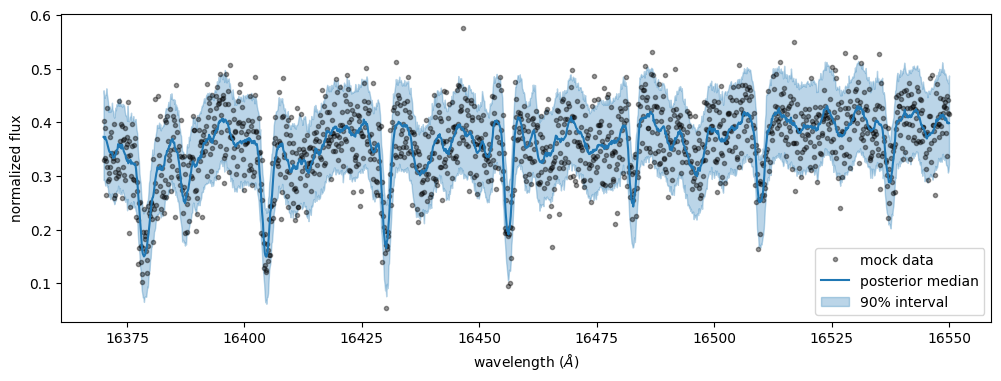

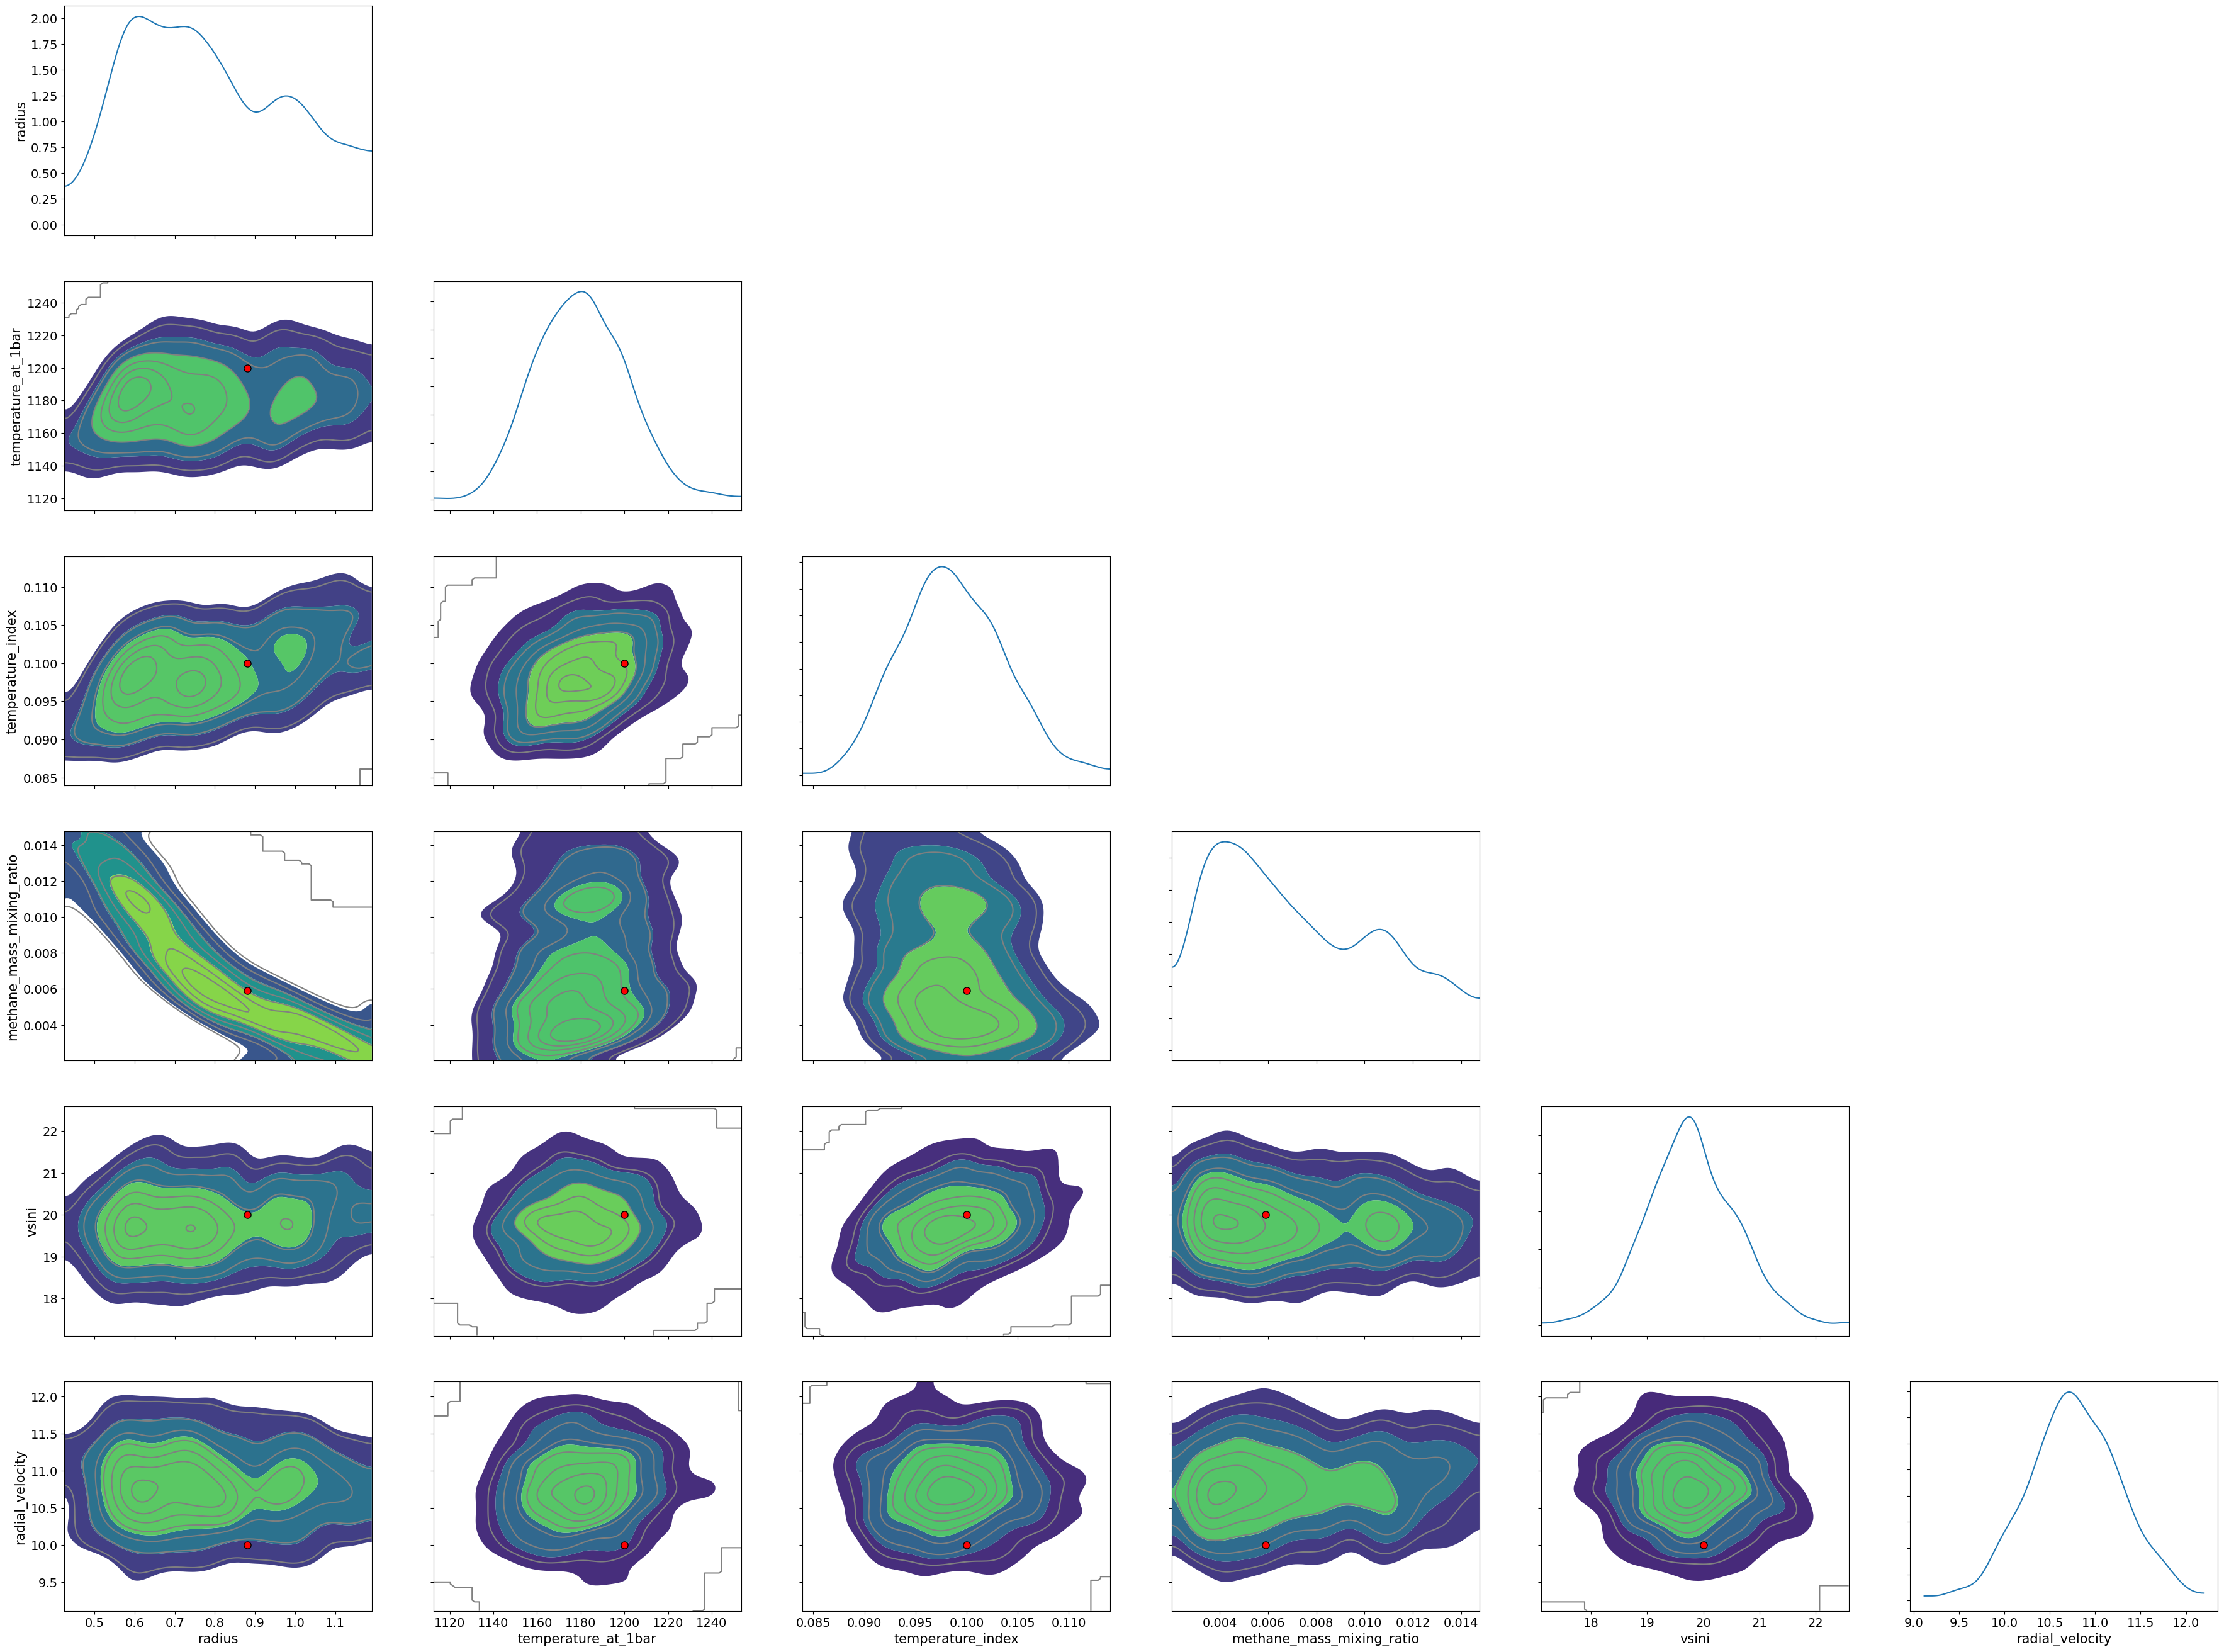

In [10]:
fig, axis = plt.subplots(figsize=(12, 4))
axis.plot(
    wavelength_data[::-1],
    observed_flux,
    ".",
    color="black",
    alpha=0.4,
    label="mock data",
)
axis.plot(
    wavelength_data[::-1],
    median_spectrum,
    color="C0",
    label="posterior median",
)
axis.fill_between(
    wavelength_data[::-1],
    spectrum_interval[0],
    spectrum_interval[1],
    color="C0",
    alpha=0.3,
    label="90% interval",
)
axis.set_xlabel("wavelength ($\\AA$)")
axis.set_ylabel("normalized flux")
axis.legend()
plt.show()

az.plot_pair(
    az.from_numpyro(mcmc, log_likelihood=False),
    var_names=[
        "radius",
        "temperature_at_1bar",
        "temperature_index",
        "methane_mass_mixing_ratio",
        "vsini",
        "radial_velocity",
    ],
    kind="kde",
    divergences=True,
    marginals=True,
    reference_values=truth,
    reference_values_kwargs={
        "color": "red",
        "marker": "o",
        "markersize": 8,
    },
)
plt.show()

## Reference benchmark against on-the-fly PreMODIT

The manual runner at `tests/benchmark/run_diffgrid_nuts_benchmark_gpu.csh` compares DiffGrid with PreMODIT cross sections evaluated on the fly. Both methods used the same serialized mock observation, forward model, priors, initial point, random seed, and NUTS configuration. Each method ran in a fresh Python process with XLA GPU preallocation disabled. The runs used 64-bit arithmetic on an NVIDIA RTX 6000 Ada Generation GPU with ExoJAX 2.4.1.dev41+g69dc7ccc2, JAX 0.6.2, and NumPyro 0.16.1. The NUTS configuration was one chain, 500 warmup steps, 1000 posterior samples, a dense mass matrix, a target acceptance probability of 0.95, and a maximum tree depth of 10.

| Metric | On-the-fly PreMODIT | DiffGrid | DiffGrid result |
| --- | ---: | ---: | ---: |
| Measured retrieval subtotal (s) | 4476.30 | 805.94 | 5.55 times faster |
| Compile and warmup (s) | 1573.26 | 289.17 | 5.44 times faster |
| Cold sampling call (s) | 2899.34 | 514.07 | 5.64 times faster |
| Cold sampling time per leapfrog step (ms) | 10.239 | 1.551 | 6.60 times faster |
| Median compiled potential-and-gradient evaluation (ms) | 10.946 | 2.241 | 4.88 times faster |
| Peak device memory (GiB) | 1.519 | 0.444 | 70.75 percent lower |
| Divergences | 0 | 0 | Same |

The measured retrieval subtotal is the sum of opacity loading, model setup, compile and warmup, and the cold sampling call; it excludes process startup, preparation, diagnostics, and the isolated gradient benchmark. The DiffGrid table had 21 nodes uniformly spaced in inverse temperature between 400 and 1500 K, a shape of `(100, 21, 7500)`, and a payload of 252,000,000 bytes (240.3 MiB). Its incremental construction took 2.071 s after the PreMODIT teacher was available, excluding molecular-database loading, teacher construction, and serialization. The gradient row is the median of five compiled potential-and-gradient evaluations at the generating point. From those timings, the construction cost is recovered after about 238 evaluations. The largest flux difference over the mock parameters and the four temperature-prior corners was `6.25e-4` times the per-pixel noise standard deviation.

The sampling calls include compilation of the sampling scan on first use. NUTS also selected different trajectory lengths: 283,172 total leapfrog steps for PreMODIT and 331,406 for DiffGrid. The per-step and isolated-gradient measurements therefore provide important context for the wall times. Peak device memory is the fresh-process JAX allocator statistic, not total memory reported by `nvidia-smi`. These are single-chain, single-seed measurements on one GPU; both performance and the five-profile interpolation check are specific to this example.

## Notes for production retrievals

- A DiffGrid table is valid only for the pressure profile used to construct it. Rebuild the table if the number of layers or any layer pressure changes.
- Every temperature evaluated by the likelihood must remain inside the table range. This example enforces that condition with `art.change_temperature_range`; other parameterizations should derive the full prior temperature envelope explicitly.
- Repeat the error-in-noise check with the actual database, atmospheric model, priors, and noise level. Increase the inverse-temperature node density until interpolation error is negligible for the inference.
- The PreMODIT teacher and molecular database may be released after construction. A saved DiffGrid archive can later be loaded without either object.
- Use the same JAX precision when saving and loading a table, or load with `strict=False` only after deciding that dtype conversion is acceptable.
- The appropriate number of nodes and the speed-up are model-, grid-, backend-, and hardware-dependent.